In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../dataset/california_housing.csv")
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.shape

(20640, 10)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [5]:
df.isnull().sum()


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [8]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())


In [9]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [10]:
df.duplicated().sum()


np.int64(0)

In [11]:
df.drop_duplicates(inplace=True)


In [13]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns


In [14]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) | 
          (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]


In [15]:
df.shape


(17609, 10)

In [16]:
# # Data Cleaning Summary

# Missing values in the total_bedrooms feature were handled 
# using median imputation to reduce the influence of extreme values.
#  Duplicate records were checked and removed to avoid bias. 
# Outliers were detected and treated using the IQR method to improve model stability.

In [19]:

import matplotlib.pyplot as plt
import seaborn as sns




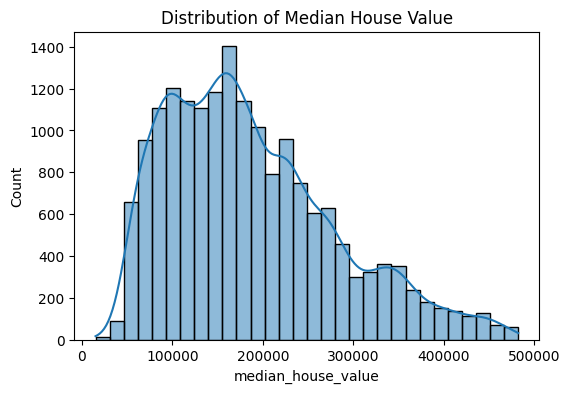

In [23]:
plt.figure(figsize=(6,4))
sns.histplot(df['median_house_value'], bins=30, kde=True)
plt.title("Distribution of Median House Value")
plt.show()


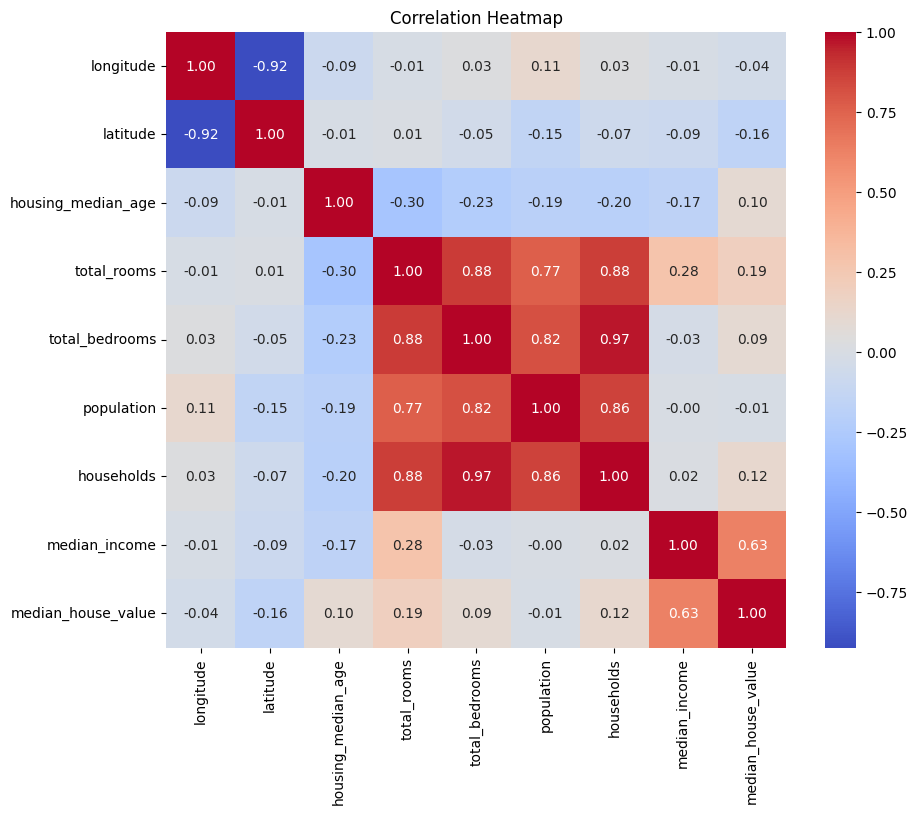

In [21]:
plt.figure(figsize=(10,8))
corr = df.select_dtypes(include=["int64", "float64"]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


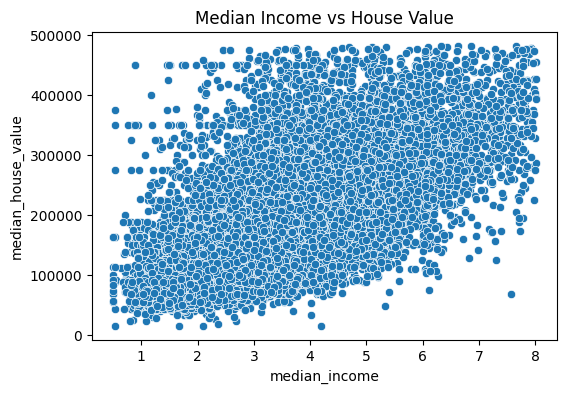

In [24]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['median_income'], y=df['median_house_value'])
plt.title("Median Income vs House Value")
plt.show()


In [25]:
#EDA Observations
#The distribution of the target variable shows a right-skewed pattern, indicating the presence of higher-priced housing regions. 
# Correlation analysis reveals that median income has a strong positive relationship with median house value.
#  Some features show moderate correlation with each other, indicating potential multicollinearity,
#  which is acceptable for exploratory linear regression analysis.

In [26]:
X = df.drop(columns=['median_house_value'])
y = df['median_house_value']


In [36]:
X = df.drop(columns=['median_house_value'])

# One-hot encode categorical column
X = pd.get_dummies(X, drop_first=True)

y = df['median_house_value']


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
y_pred = model.predict(X_test)


In [41]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients.sort_values(by='Coefficient', ascending=False)


,Feature,Coefficient
9,ocean_proximity_ISLAND,157203.671202
7,median_income,39246.638037
2,housing_median_age,873.702329
4,total_bedrooms,141.078005
6,households,108.417199
3,total_rooms,-12.540932
5,population,-60.429096
11,ocean_proximity_NEAR OCEAN,-2565.903982
10,ocean_proximity_NEAR BAY,-10153.830670
1,latitude,-23456.265165


In [42]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)


Mean Squared Error (MSE): 3476449847.944595
R² Score: 0.6200183671236132


In [43]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

coefficients


,Feature,Coefficient
9,ocean_proximity_ISLAND,157203.671202
7,median_income,39246.638037
2,housing_median_age,873.702329
4,total_bedrooms,141.078005
6,households,108.417199
3,total_rooms,-12.540932
5,population,-60.429096
11,ocean_proximity_NEAR OCEAN,-2565.903982
10,ocean_proximity_NEAR BAY,-10153.830670
1,latitude,-23456.265165


In [44]:
# ### Model Evaluation and Interpretation
# The linear regression model was evaluated using Mean Squared Error (MSE) and R² score.
#  A lower MSE indicates better prediction accuracy, while the R² score reflects how well the model explains variability in the target variable. 
# The obtained R² value suggests a reasonably good linear relationship between the input features and median house value.

# Coefficient analysis shows that median income has the strongest positive influence on house prices, while location-related features also play a significant role. 
# This confirms that socioeconomic and geographical factors are key determinants of housing prices.